In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [66]:
df = pd.read_csv('Student Depression Dataset.csv')

In [67]:
df = df.drop(columns = ['id'])
df

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [68]:
df['Financial Stress'] = df['Financial Stress'].fillna(df['Financial Stress'].mean())

In [69]:
df = df[df['Profession'] == 'Student']

In [70]:
df = df.drop(columns = ['Job Satisfaction', 'Work Pressure', 'City'])

In [71]:
df = df[df['Dietary Habits'] != 'Others']

In [72]:
df['Sleep Duration'] = df['Sleep Duration'].replace("Others", "More than 8 hours")

In [73]:
df['Gender'] = df['Gender'].map({"Male" : 0, "Female" : 1})

In [74]:
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map({"No" : 0, "Yes" : 1})
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map({"No" : 0, "Yes" : 1})

In [75]:
df['Dietary Habits'] = df['Dietary Habits'].map({"Unhealthy" : 0,"Moderate" : 1, "Healthy" : 2})
df['Sleep Duration'] = df['Sleep Duration'].map({'Less than 5 hours' : 0,'5-6 hours' : 1,'7-8 hours' : 2,'More than 8 hours' : 3})

In [76]:
df = pd.get_dummies(df, columns = ['Degree'],drop_first=True, dtype = int)

In [77]:
df = df.drop('Profession', axis = 1)

In [78]:
df

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,...,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD
0,0,33.0,5.0,8.97,2.0,1,2,1,3.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,1,24.0,2.0,5.90,5.0,1,1,0,3.0,2.0,...,0,0,0,0,0,0,0,0,0,0
2,0,31.0,3.0,7.03,5.0,0,2,0,9.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,1,28.0,3.0,5.59,2.0,2,1,1,4.0,5.0,...,0,0,0,0,0,0,0,0,0,0
4,1,25.0,4.0,8.13,3.0,1,1,1,1.0,1.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,1,27.0,5.0,5.75,5.0,1,0,1,7.0,1.0,...,0,0,0,0,0,0,0,0,0,0
27897,0,27.0,2.0,9.40,3.0,0,2,0,0.0,3.0,...,0,0,0,0,0,0,0,1,0,0
27898,0,31.0,3.0,6.61,4.0,1,0,0,12.0,2.0,...,0,0,0,0,1,0,0,0,0,0
27899,1,18.0,5.0,6.88,2.0,0,2,1,10.0,5.0,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='Work/Study Hours', ylabel='Count'>

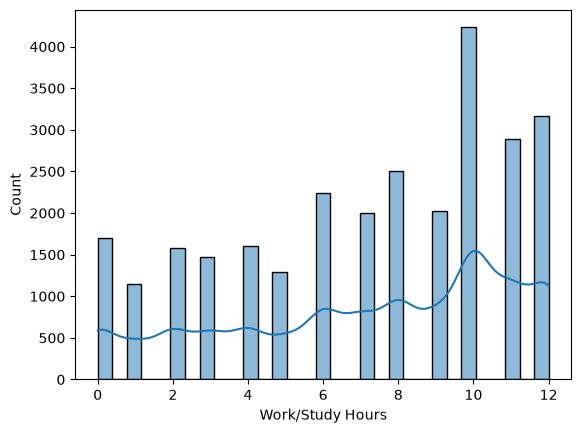

In [79]:
sns.histplot(df['Work/Study Hours'],kde =True)

In [80]:
from sklearn.model_selection import train_test_split

# 1. Define X and y
X = df.drop('Depression', axis=1) # axis=1 means drop the column
y = df['Depression']

# 2. Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [82]:
lr_model = LogisticRegression(random_state=42)

In [83]:
lr_model.fit(X_train_scaled,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [84]:
y_pred_lr = lr_model.predict(X_test)

In [85]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr)*100)

Logistic Regression Accuracy: 52.440775305096906


In [86]:
from sklearn.model_selection import GridSearchCV

params_lr ={
    'C': [0.01, 0.1, 1, 10, 100],   
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] 
}

lr_search = GridSearchCV(
    estimator = LogisticRegression(random_state=42),
    param_grid = params_lr,
    cv = 5,
    scoring = 'accuracy',
)

lr_search.fit(X_train_scaled,y_train)
print("Best Parameters:", lr_search.best_params_)
print("Best Accuracy Score:", lr_search.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best Accuracy Score: 0.8463612367739467


In [88]:
from sklearn.metrics import accuracy_score, classification_report

# The grid search automatically saved the best model
best_lr_model = lr_search.best_estimator_

final_preds = best_lr_model.predict(X_test_scaled)

print("Final Optimized LR Accuracy:", accuracy_score(y_test, final_preds)*100)
print("\nClassification Report:")
print(classification_report(y_test, final_preds))

Final Optimized LR Accuracy: 85.1040918880115

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      2266
           1       0.86      0.89      0.88      3306

    accuracy                           0.85      5572
   macro avg       0.85      0.84      0.84      5572
weighted avg       0.85      0.85      0.85      5572



In [91]:
import joblib
joblib.dump(best_lr_model,'depression_model.pkl')
joblib.dump(scaler,'scaler.pkl')
print("Saved successfully!")

Saved successfully!


In [98]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# 1. Load the saved model and scaler
model = joblib.load('depression_model.pkl')
scaler = joblib.load('scaler.pkl')

# 2. Set up the App Title and Description
st.title("🧠 Student Depression Risk Predictor")
st.write("Fill in the student's details below. The model will predict the likelihood of depression.")

# 3. Create the User Inputs (with nice sliders and dropdowns)
col1, col2 = st.columns(2)

with col1:
    age = st.slider("Age", 18, 35, 20)
    gender = st.selectbox("Gender", ["Male", "Female"])
    academic_pressure = st.slider("Academic Pressure (1-5)", 1, 5, 3)
    study_satisfaction = st.slider("Study Satisfaction (1-5)", 1, 5, 3)
    cgpa = st.slider("CGPA", 0.0, 10.0, 7.0, step=0.1)

with col2:
    sleep_duration = st.selectbox("Sleep Duration", ["Less than 5 hours", "5-6 hours", "7-8 hours", "More than 8 hours"])
    dietary_habits = st.selectbox("Dietary Habits", ["Unhealthy", "Moderate", "Healthy"])
    suicidal_thoughts = st.selectbox("Suicidal Thoughts?", ["No", "Yes"])
    financial_stress = st.slider("Financial Stress (1-5)", 1, 5, 3)
    family_history = st.selectbox("Family History of Mental Illness?", ["No", "Yes"])

work_hours = st.slider("Work/Study Hours", 0, 12, 5)

# Degree Selection (We need to map this to the One-Hot Encoded columns)
# Note: If B.Arch was dropped by drop_first=True, it is the "default" if all others are 0
degrees_list = ["B.Arch", "B.Com", "B.Ed", "B.Pharm", "B.Tech", "BA", "BBA", "BCA", "BE", 
                "BHM", "BSc", "Class 12", "LLB", "LLM", "M.Com", "M.Ed", "M.Pharm", 
                "M.Tech", "MA", "MBA", "MBBS", "MCA", "MD", "ME", "MHM", "MSc", "Others", "PhD"]
degree = st.selectbox("Degree", degrees_list)

# 4. The "Under the Hood" Mapping (Translating text to the numbers the model expects)
input_data = {
    'Gender': 1 if gender == "Female" else 0,
    'Age': age,
    'Academic Pressure': academic_pressure,
    'CGPA': cgpa,
    'Study Satisfaction': study_satisfaction,
    'Sleep Duration': {"Less than 5 hours": 0, "5-6 hours": 1, "7-8 hours": 2, "More than 8 hours": 3}[sleep_duration],
    'Dietary Habits': {"Unhealthy": 0, "Moderate": 1, "Healthy": 2}[dietary_habits],
    'Have you ever had suicidal thoughts ?': 1 if suicidal_thoughts == "Yes" else 0,
    'Work/Study Hours': work_hours,
    'Financial Stress': financial_stress,
    'Family History of Mental Illness': 1 if family_history == "Yes" else 0
}

# Add the One-Hot Encoded Degree columns (All start at 0)
degree_columns = ['Degree_B.Com', 'Degree_B.Ed', 'Degree_B.Pharm', 'Degree_B.Tech', 'Degree_BA', 
                  'Degree_BBA', 'Degree_BCA', 'Degree_BE', 'Degree_BHM', 'Degree_BSc', 
                  'Degree_Class 12', 'Degree_LLB', 'Degree_LLM', 'Degree_M.Com', 'Degree_M.Ed', 
                  'Degree_M.Pharm', 'Degree_M.Tech', 'Degree_MA', 'Degree_MBA', 'Degree_MBBS', 
                  'Degree_MCA', 'Degree_MD', 'Degree_ME', 'Degree_MHM', 'Degree_MSc', 
                  'Degree_Others', 'Degree_PhD']

for col in degree_columns:
    input_data[col] = 0

# If the user selected a degree that has a column, set it to 1
degree_col_name = f"Degree_{degree}"
if degree_col_name in input_data:
    input_data[degree_col_name] = 1
# (If they select B.Arch, it was dropped by drop_first=True, so all remain 0, which is correct!)

# 5. Predict Button
if st.button("Predict Depression Risk"):
    # Put the data in the exact column order the model expects
    features = pd.DataFrame([input_data])
    
    # Scale the data (CRITICAL STEP)
    features_scaled = scaler.transform(features)
    
    # Predict
    prediction = model.predict(features_scaled)[0]
    probability = model.predict_proba(features_scaled)[0][1] # Chance of class 1
    
    # Display Results
    st.subheader("Result:")
    if prediction == 1:
        st.error(f"⚠️ High Risk of Depression (Confidence: {probability*100:.1f}%)")
    else:
        st.success(f"✅ Low Risk of Depression (Confidence: {(1-probability)*100:.1f}%)")

Writing app.py
